# Phase 2 — Inter-subject correlation of heart rate (ISC-HR)

the first real inter-subject 
correlation of heart rate (ISC-HR) computed on the BBBD dataset, Experiment 2, session
ses-01 (Attentive), stimulus stim0 So.this notebook is going to measurees how muctheir heart-rate
fluctuations move in syn.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from isc_analysis import collect_hr_series, align_series, correlation_matrix, isc_hr

## Configuration

Set `EXPERIMENT_ROOT` to the Experiment 2 root on your machine (the folder that
directly contains `sub-01`, `sub-02`, ...).

In [2]:
EXPERIMENT_ROOT = 'data'  
SESSION = 'ses-01'         # ses-01 = Attentive, ses-02 = Distracted
STIM = 'stim01'

## Collect the HR series of all subjects

The `collect_hr_series` function runs the whole pipeline(loading, filtering, peak detection, instantaneous HR, interpolation) on each subject for this specific session and stimulus and returns one interpolated HR series per subject. Subjects whose file is missing are skipped (BBBD numbering is not contiguous).

Subject 35 has only 49 peaks and a mean HR of 35.7 BPM. This suggests the peak-detection thresold failed on this subject's recording or it's just an outlier. The decision is to exclude it to get a better quality data from the analysis.

In [7]:
ids, series = collect_hr_series(EXPERIMENT_ROOT, SESSION, STIM, verbose=True)
print(f'\n{len(ids)} subjects collected')

keep = [i for i, s in enumerate(ids) if s != 'sub-35']
ids = [ids[i] for i in keep]
series = [series[i] for i in keep]
print(f'{len(ids)} subjects after excluding sub-35')

  sub-01: 157 peaks, mean HR 51.0 BPM, 731 samples
  sub-02: 199 peaks, mean HR 64.5 BPM, 735 samples
  sub-03: 250 peaks, mean HR 81.5 BPM, 735 samples
  sub-05: 256 peaks, mean HR 83.6 BPM, 733 samples
  sub-06: 242 peaks, mean HR 78.9 BPM, 733 samples
  sub-07: 249 peaks, mean HR 81.3 BPM, 732 samples
  sub-08: file missing, skipped
  sub-09: 295 peaks, mean HR 96.2 BPM, 733 samples
  sub-12: 237 peaks, mean HR 77.4 BPM, 734 samples
  sub-13: 199 peaks, mean HR 65.0 BPM, 733 samples
  sub-14: 219 peaks, mean HR 71.6 BPM, 733 samples
  sub-15: 228 peaks, mean HR 74.4 BPM, 732 samples
  sub-16: 203 peaks, mean HR 66.9 BPM, 731 samples
  sub-18: 233 peaks, mean HR 76.3 BPM, 731 samples
  sub-19: 225 peaks, mean HR 73.4 BPM, 733 samples
  sub-20: 233 peaks, mean HR 76.0 BPM, 733 samples
  sub-21: 229 peaks, mean HR 76.1 BPM, 732 samples
  sub-22: 207 peaks, mean HR 67.8 BPM, 731 samples
  sub-23: 226 peaks, mean HR 73.6 BPM, 734 samples
  sub-24: 235 peaks, mean HR 76.7 BPM, 732 samples

## Align and build the correlation matrix (Step 3)

Series differ slightly in length, so they are truncated to the shortest common
length before correlating (Pearson needs equal-length vectors).

The `correlation_matrix` function then computes the Pearson correlation coefficient between every pair of the 28 subjects, producing a 28x28 symmetric matrix.

In [8]:
aligned = align_series(series)
corr = correlation_matrix(aligned)
print(f'Aligned to {aligned.shape[1]} samples each')
print(f'Correlation matrix shape: {corr.shape}')

Aligned to 729 samples each
Correlation matrix shape: (27, 27)


## The correlation matrix

Entry (i, j) is the Pearson correlation between subject i and subject j. The
dark diagonal is each subject with itself (r = 1). This is the equivalent of
Figure 1C in the paper.


**What to observe**:

The off-diagonal cells are predominantly light red/pink, indicating a weak but broadly positive correlation across most subject pairs. This is consistent with a shared, stimulus-driven fluctuation in heart rate.

Only a few pairs show light blue which is a weak negative correlation. This is expected because not every pair needs to be positively correlated for the group average to be positive.

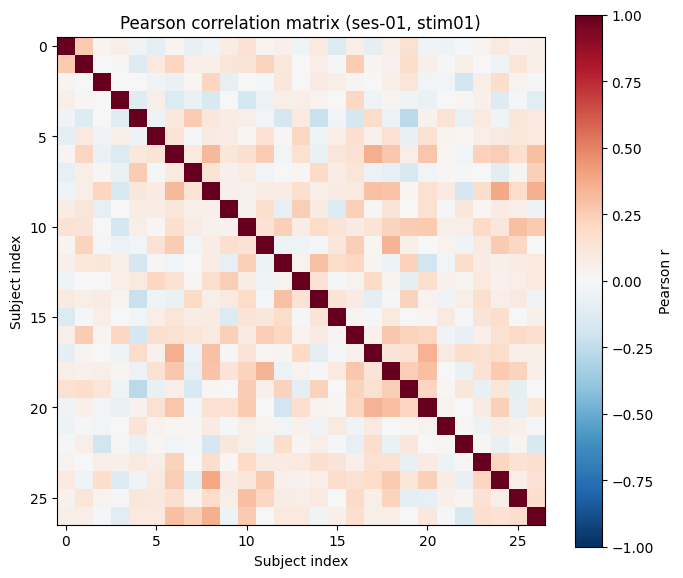

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xlabel('Subject index')
ax.set_ylabel('Subject index')
ax.set_title(f'Pearson correlation matrix ({SESSION}, {STIM})')
plt.colorbar(im, label='Pearson r')
plt.tight_layout()
plt.show()

## ISC-HR per subject (Steps 4-5)

For each subject, ISC-HR averages the Fisher-Z transformed correlations to the rest of
the group(excluding self-correlations). Then it applies the inverse transform.

**What to observe in the output**:
ISC_HR is a Person correlation. Values near +1 indicate strong synchrony (HR fluctuations move together), while values near 0 indicate no synchrony. Negative values indicate the subject's HR tends to move opposite to the group.

ISC-HR mean of the group is **0.068**, with individual subjects ranging from -0.021 to 0.136. 
What matters is not the raw size of the value but whether it is systematically above zero rather than scattered symmetrically arount it. 
The majority of subjects in the bar chart sit above zero. 

In order to establish if this mean is statistically distinguishable from zero, rather than a chance fluctuation, is the role of the hypothesis test, not yet implemented at this stage.

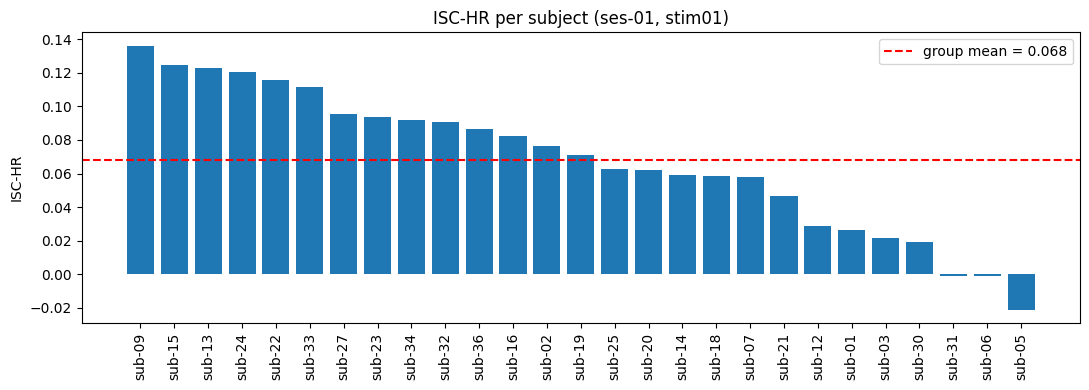

Group mean ISC-HR: 0.068
Range: -0.021 to 0.136


In [10]:
isc = isc_hr(corr)
order = np.argsort(isc)[::-1]   # sort descending for readability

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(isc)), isc[order])
ax.axhline(isc.mean(), color='red', linestyle='--', label=f'group mean = {isc.mean():.3f}')
ax.set_xticks(range(len(isc)))
ax.set_xticklabels([ids[i] for i in order], rotation=90)
ax.set_ylabel('ISC-HR')
ax.set_title(f'ISC-HR per subject ({SESSION}, {STIM})')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Group mean ISC-HR: {isc.mean():.3f}')
print(f'Range: {isc.min():.3f} to {isc.max():.3f}')